# Station-MAE — Test Results

Four analyses, all computed from the saved `predictions.pt` dumps (full sliding test set):

1. **Effect of masking** — mr0.50 vs mr0.00 on the *masked* stations (v9, v11)
2. **Model comparison vs persistence** — per-variable, per lead-time (mr0.50)
3. **Terrain** — valley vs mountainous stations
4. **Per-station × variable × season** — which stations work and which don't

Errors are in **physical units** (per-station training σ). Files are ~1.6 GB each, so
§0 aggregates one run at a time and keeps only small summary tables — the raw arrays
are never all in memory at once.

In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
import os, sys, glob, datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

RESULTS_ROOT = "test_results"
EXCLUDE      = ["PFA"]
CHUNK        = 2000          # windows processed at a time (memory control)

# Terrain split (§3) — a station is "mountain" if it is high OR steep.
ALT_THRESH   = 1000.0        # m
SLOPE_THRESH = 7.0           # SLOPE_2000M_SIGRATIO1

VARS   = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]
UNITS  = {"temperature":"°C","pressure":"hPa","humidity":"%","wind_u":"m/s","wind_v":"m/s"}
SEASONS = ["DJF","MAM","JJA","SON"]
COLORS = {"v9":"#2E7D8C","v11":"#D9663D","lstm-baseline-v1":"#6A4C93","persistence":"#444444"}

_CAND = ["/home/renku/work/PeakWeatherDataset",
         os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
         os.path.expanduser("~/PeakWeatherDataset"), "PeakWeatherDataset"]
DATA_ROOT = next((p for p in _CAND if os.path.isdir(p)), _CAND[-1])
plt.rcParams.update({"figure.dpi":110, "font.size":10})

# discover available runs: {run: {mask_ratio: path}}
RUNS = {}
for p in sorted(glob.glob(os.path.join(RESULTS_ROOT, "*", "best_mr*", "predictions.pt"))):
    run = p.split(os.sep)[-3]; mr = p.split(os.sep)[-2].replace("best_", "")
    RUNS.setdefault(run, {})[mr] = p
for r, d in RUNS.items():
    print(f"{r:20s} {sorted(d)}")

lstm-baseline-v1     ['mr0.00']
v9                   ['mr0.00', 'mr0.50']


In [2]:
# ── Station metadata: physical scale + terrain class ─────────────────────────
from data.dataset import load_peakweather, StationMAEDataset, compute_obs_stats
ds   = load_peakweather(root=DATA_ROOT)
keep = StationMAEDataset._resolve_keep_indices(ds, EXCLUDE)
STN  = [ds.stations_table.index[i] for i in keep]          # station ids, prediction order
N    = len(STN)

# per-(station, variable) training σ → physical units
_st   = compute_obs_stats(ds, train_years=None, per_station=True)
STD   = np.clip(_st["std"].numpy()[keep][:, :5], 1e-6, None)          # (N, 5)

# terrain
_t     = ds.stations_table.loc[STN]
alt    = _t["station_height"].astype(float).values
slope  = _t["SLOPE_2000M_SIGRATIO1"].astype(float).values
IS_MTN = (alt >= ALT_THRESH) | (slope >= SLOPE_THRESH)                # (N,) bool

# Guard: the station axis of the dumps must match this station list exactly.
# (load_peakweather drops stations lacking the requested parameters, so the raw
#  stations table is larger than the modelled network — never index it directly.)
import torch as _t
_probe = _t.load(next(iter(next(iter(RUNS.values())).values())),
                 map_location="cpu", weights_only=False)["preds"].shape[2]
assert _probe == N, (f"station mismatch: predictions have {_probe} stations but the "
                     f"dataset resolved {N}. Check EXCLUDE={EXCLUDE}.")
del _probe

print(f"stations: {N}   mountain: {IS_MTN.sum()}   valley: {(~IS_MTN).sum()}")
print(f"  mountain: alt {alt[IS_MTN].mean():.0f} m, slope {slope[IS_MTN].mean():.1f}")
print(f"  valley  : alt {alt[~IS_MTN].mean():.0f} m, slope {slope[~IS_MTN].mean():.1f}")

stations: 155   mountain: 74   valley: 81
  mountain: alt 1620 m, slope 8.5
  valley  : alt 540 m, slope 2.0


## 0. Aggregation pass

Each dump is streamed in chunks; we accumulate absolute-error sums and counts at the
granularity every later section needs, then release the arrays. **Persistence** is
derived from the same file (`targets[:, 0]` = the last observation carried forward),
so it sits on identical windows and masks.

In [3]:
# ── Stream each run and accumulate summary tables ────────────────────────────
import torch

def _season_idx(hours):                     # hours since epoch → 0..3
    ep = datetime.datetime(1970,1,1)
    m  = np.array([(ep + datetime.timedelta(hours=float(h))).month for h in hours.ravel()])
    s  = np.select([np.isin(m,[12,1,2]), np.isin(m,[3,4,5]), np.isin(m,[6,7,8])], [0,1,2], 3)
    return s.reshape(hours.shape)

def aggregate(path):
    """Return dicts of summed |err| and counts at several granularities."""
    d = torch.load(path, map_location="cpu", weights_only=False)
    P, T, M = d["preds"], d["targets"], d["masks"]
    TH, MI  = d["target_hours"], d.get("masked_idx")
    Mw, K   = P.shape[0], P.shape[1]
    A = {k: np.zeros(sh) for k, sh in {
        "kv":(K,len(VARS)), "kv_p":(K,len(VARS)),          # per horizon (model, persistence)
        "kv_m":(K,len(VARS)), "kv_m_p":(K,len(VARS)),      # per horizon, MASKED stations only
        "sv":(N,len(VARS)), "svs":(N,len(VARS),4),          # per station / station×season
    }.items()}
    C = {k: np.zeros(sh) for k, sh in {
        "kv":(K,len(VARS)), "kv_m":(K,len(VARS)),
        "sv":(N,len(VARS)), "svs":(N,len(VARS),4)}.items()}

    for a in range(0, Mw, CHUNK):
        b   = min(a+CHUNK, Mw)
        p   = P[a:b].numpy(); t = T[a:b,:,:,:5].numpy(); m = M[a:b,:,:,:5].numpy() > 0.5
        err = np.abs(p - t) * STD[None,None,:,:]                     # (c,K,N,V) physical
        t0  = T[a:b,0:1,:,:5].numpy()                                # persistence prediction
        m0  = M[a:b,0:1,:,:5].numpy() > 0.5
        errp= np.abs(t0 - t) * STD[None,None,:,:]
        mp  = m & m0                                                 # valid at Δ0 AND horizon
        sea = _season_idx(TH[a:b].numpy())                           # (c,K)

        A["kv"]   += (err*m ).sum(axis=(0,2));  C["kv"]  += m.sum(axis=(0,2))
        A["kv_p"] += (errp*mp).sum(axis=(0,2))
        C["kv_m"] += 0  # filled below only if masking present

        if MI is not None and MI.shape[1] > 0:                       # masked-station subset
            mi  = MI[a:b].numpy()
            sel = np.zeros((b-a, N), bool)
            np.put_along_axis(sel, mi, True, axis=1)
            sm  = m  & sel[:,None,:,None]
            smp = mp & sel[:,None,:,None]
            A["kv_m"]   += (err*sm ).sum(axis=(0,2)); C["kv_m"] += sm.sum(axis=(0,2))
            A["kv_m_p"] += (errp*smp).sum(axis=(0,2))

        A["sv"] += (err*m).sum(axis=(0,1)); C["sv"] += m.sum(axis=(0,1))
        for si in range(4):                                          # station × season
            w = (sea == si)                                          # (c,K)
            if not w.any(): continue
            ww = w[:,:,None,None]
            A["svs"][:,:,si] += (err*m*ww).sum(axis=(0,1))
            C["svs"][:,:,si] += (m*ww).sum(axis=(0,1))
        del p,t,m,err,t0,m0,errp,mp,sea
    grid = d["delta_steps"][0].numpy().astype(int)
    del d, P, T, M
    return A, C, grid

AGG = {}
for run, mrs in RUNS.items():
    for mr, path in mrs.items():
        A, C, GRID = aggregate(path)
        AGG[(run, mr)] = (A, C)
        print(f"  aggregated {run:20s} {mr}")
LEAD = [f"+{int(g)*10}min" if 0 < int(g)*10 < 60 else ("t=0" if g==0 else f"+{int(g)*10//60}h")
        for g in GRID]
print("horizons:", LEAD)

  aggregated lstm-baseline-v1     mr0.00
  aggregated v9                   mr0.00
  aggregated v9                   mr0.50
horizons: ['t=0', '+30min', '+1h', '+1h', '+2h', '+2h', '+3h', '+3h', '+4h', '+4h', '+5h', '+5h', '+6h']


## 1. Effect of masking — mr0.50 vs mr0.00, on the masked stations

The stations hidden at mr0.50 (`masked_idx`) are evaluated in **both** runs, so the
comparison isolates what the encoder loses by not seeing them. mr0.00 is the same
stations *visible*; mr0.50 is the same stations *inferred from neighbours*.

In [4]:
# ── Masked-station error: mr0.00 vs mr0.50, per variable ────────────────────
rows = {}
for run in [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]:
    A5, C5 = AGG[(run,"mr0.50")]
    A0, C0 = AGG[(run,"mr0.00")]
    for vi, v in enumerate(VARS):
        # restrict BOTH to the stations masked in the mr0.50 run
        vis  = A0["kv_m"][:,vi].sum() / max(C0["kv_m"][:,vi].sum(), 1) if C0["kv_m"][:,vi].sum() else np.nan
        hid  = A5["kv_m"][:,vi].sum() / max(C5["kv_m"][:,vi].sum(), 1)
        # mr0.00 has no masked_idx → fall back to all-station error as the "visible" ref
        if not np.isfinite(vis) or vis == 0:
            vis = A0["kv"][:,vi].sum() / max(C0["kv"][:,vi].sum(), 1)
        rows[(run, v)] = {"MAE visible (mr0.00)": vis, "MAE masked (mr0.50)": hid,
                          "Δ": hid - vis, "× worse": hid/vis if vis else np.nan}
if rows:
    t = pd.DataFrame(rows).T; t.index.names = ["run","variable"]
    display(t.style.format({"MAE visible (mr0.00)":"{:.3f}","MAE masked (mr0.50)":"{:.3f}",
                            "Δ":"{:+.3f}","× worse":"{:.2f}×"})
            .set_caption("Cost of hiding a station — physical units "
                         + ", ".join(f"{v}[{UNITS[v]}]" for v in VARS)))
else:
    print("Need both mr0.00 and mr0.50 for a run.")

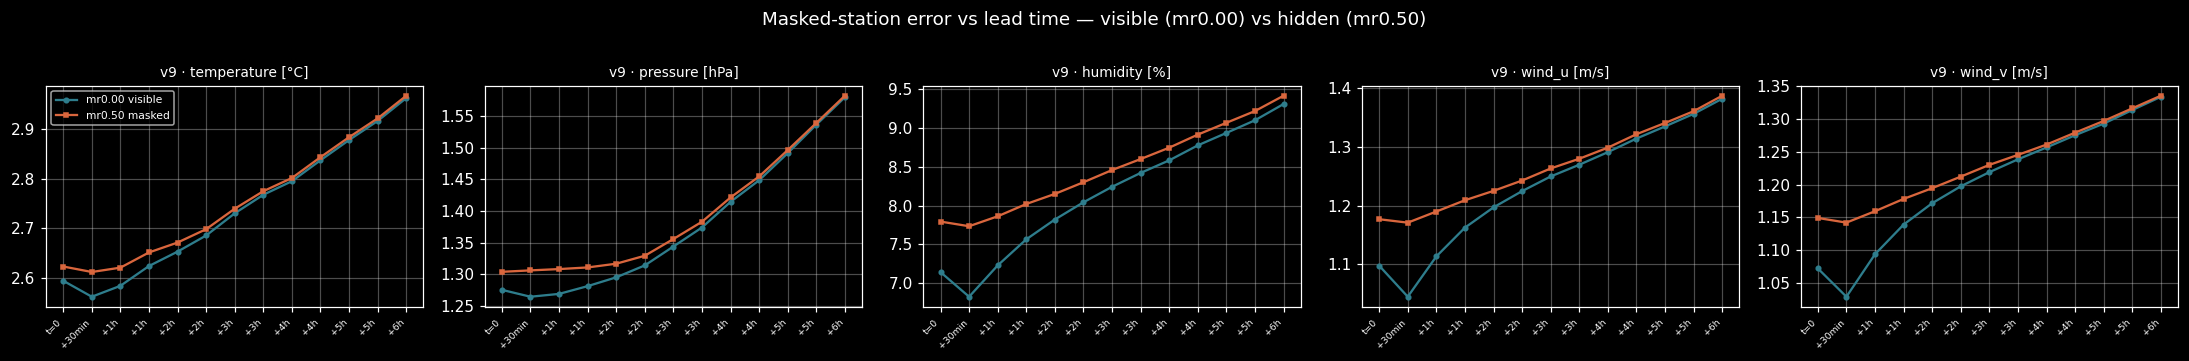

In [5]:
# ── Same comparison across lead time, per variable ───────────────────────────
runs2 = [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]
if runs2:
    fig, axes = plt.subplots(len(runs2), len(VARS), figsize=(4*len(VARS), 3.2*len(runs2)),
                             squeeze=False)
    for ri, run in enumerate(runs2):
        A5,C5 = AGG[(run,"mr0.50")]; A0,C0 = AGG[(run,"mr0.00")]
        for vi, v in enumerate(VARS):
            ax = axes[ri][vi]
            hid = A5["kv_m"][:,vi] / np.maximum(C5["kv_m"][:,vi], 1)
            vis = (A0["kv_m"][:,vi] / np.maximum(C0["kv_m"][:,vi],1)
                   if C0["kv_m"][:,vi].sum() else A0["kv"][:,vi]/np.maximum(C0["kv"][:,vi],1))
            ax.plot(range(len(GRID)), vis, "o-", color="#2E7D8C", lw=1.5, ms=3, label="mr0.00 visible")
            ax.plot(range(len(GRID)), hid, "s-", color="#D9663D", lw=1.5, ms=3, label="mr0.50 masked")
            ax.set_xticks(range(len(GRID))); ax.set_xticklabels(LEAD, rotation=45, ha="right", fontsize=6)
            ax.set_title(f"{run} · {v} [{UNITS[v]}]", fontsize=9); ax.grid(alpha=0.3)
            if vi==0: ax.legend(fontsize=7)
    fig.suptitle("Masked-station error vs lead time — visible (mr0.00) vs hidden (mr0.50)", y=1.01)
    plt.tight_layout(); plt.show()

## 2. Model comparison vs persistence

Per-variable MAE against lead time. Transformers are shown at **mr0.50** (their trained
setting); the LSTM has no masking so it appears at mr0.00 — noted on the plot, since it
solves an easier problem. Persistence is the reference.

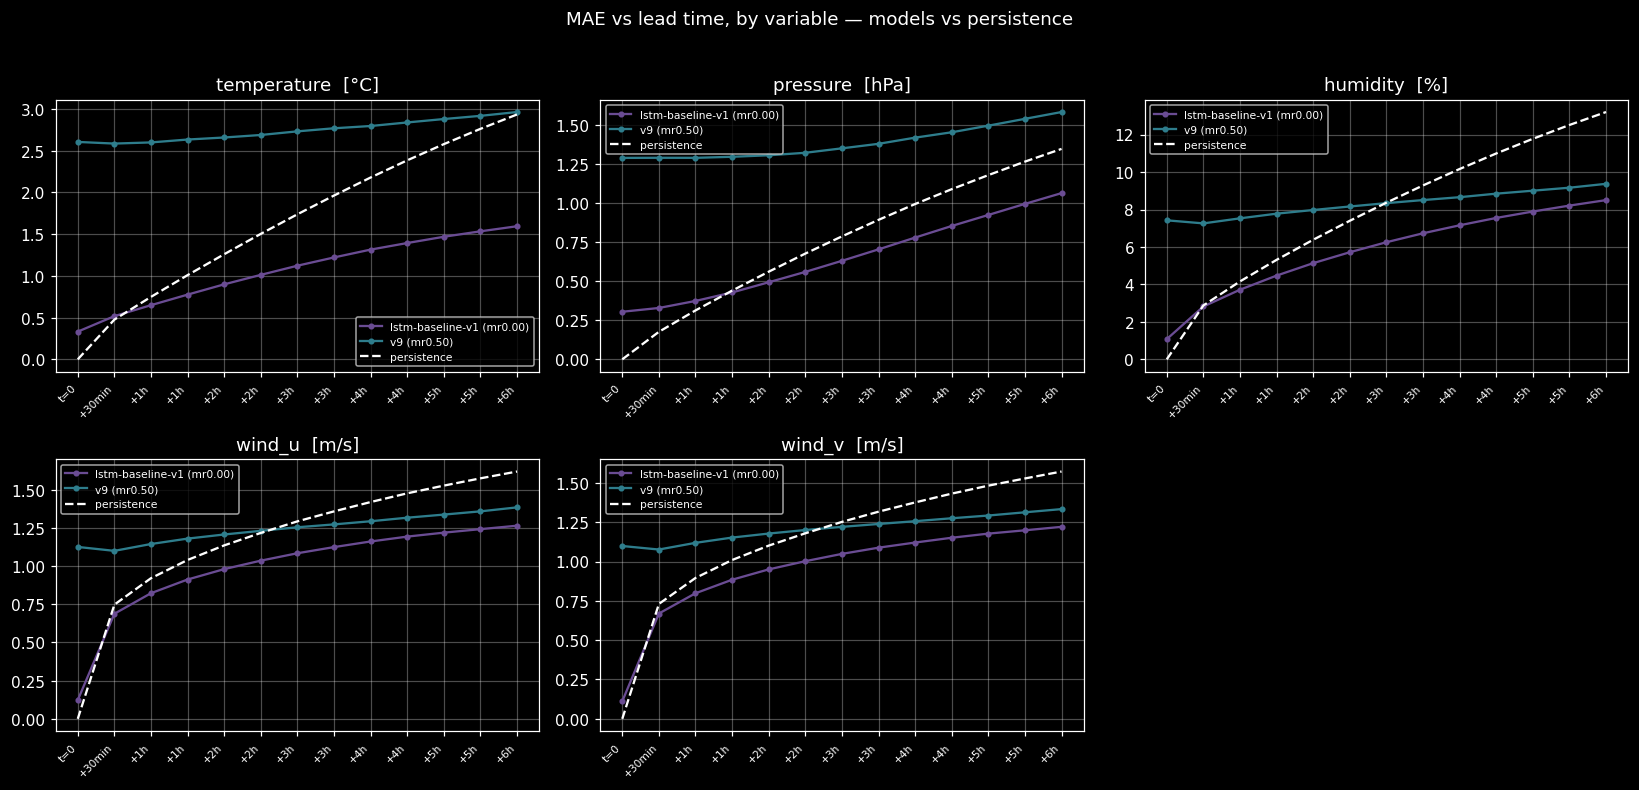

In [10]:
# ── Per-variable MAE vs lead time: models + persistence ─────────────────────
PREF = {}                       # run → mask ratio to display
for r in RUNS:
    PREF[r] = "mr0.50" if "mr0.50" in RUNS[r] else "mr0.00"

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for run, mr in PREF.items():
        A, C = AGG[(run, mr)]
        y = A["kv"][:,vi] / np.maximum(C["kv"][:,vi], 1)
        lbl = f"{run} ({mr})"
        ax.plot(range(len(GRID)), y, "o-", ms=3, lw=1.5,
                color=COLORS.get(run, "#888"), label=lbl)
    # persistence (identical across runs — take the first)
    A, C = AGG[list(AGG)[0]]
    ax.plot(range(len(GRID)), A["kv_p"][:,vi] / np.maximum(C["kv"][:,vi],1),
            "w--", lw=1.5, label="persistence")
    ax.set_xticks(range(len(GRID))); ax.set_xticklabels(LEAD, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{v}  [{UNITS[v]}]"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle("MAE vs lead time, by variable — models vs persistence", y=1.02)
plt.tight_layout(); plt.show()

# summary table + skill over Δ>0
rows = {}
Ap, Cp = AGG[list(AGG)[0]]
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        mae  = A["kv"][:,vi].sum()   / max(C["kv"][:,vi].sum(), 1)
        m_fc = A["kv"][1:,vi].sum()  / max(C["kv"][1:,vi].sum(), 1)
        p_fc = Ap["kv_p"][1:,vi].sum()/ max(Cp["kv"][1:,vi].sum(), 1)
        rows[(f"{run} ({mr})", v)] = {"MAE": mae, "MAE Δ>0": m_fc,
                                      "persistence Δ>0": p_fc,
                                      "skill": 1 - m_fc/p_fc if p_fc else np.nan}
t = pd.DataFrame(rows).T; t.index.names=["model","variable"]
display(t.style.format({"MAE":"{:.3f}","MAE Δ>0":"{:.3f}","persistence Δ>0":"{:.3f}",
                        "skill":"{:+.3f}"})
        .set_caption("Skill > 0 means better than persistence"))

## 3. Terrain — valley vs mountainous stations

Stations are split by altitude and slope (`ALT_THRESH`, `SLOPE_THRESH` at the top).
Complex terrain is where spatial interpolation is hardest, so this is the clearest test
of whether the models cope with the Alps.

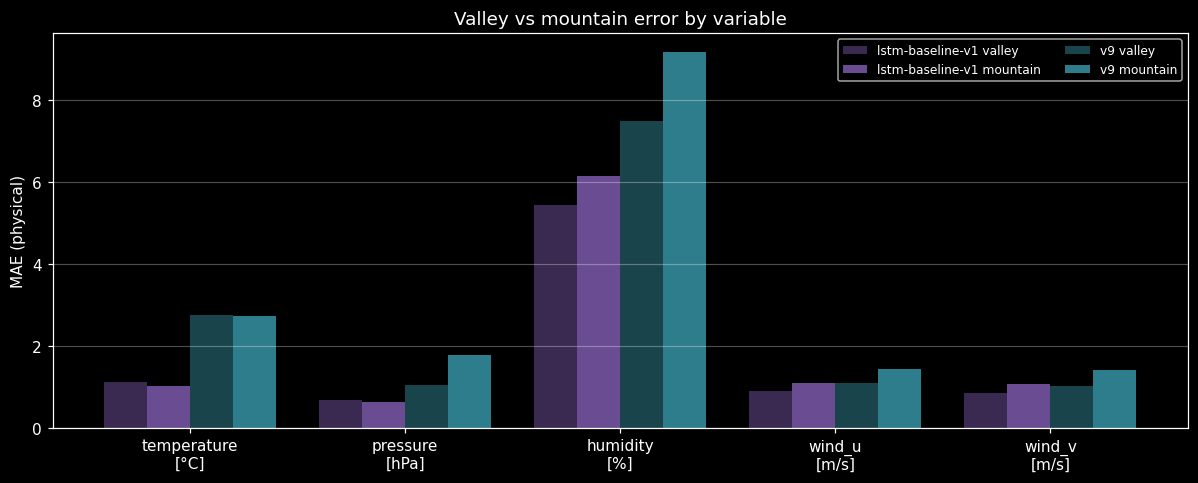

In [7]:
# ── Error by terrain class, per variable and model ───────────────────────────
rows = {}
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        for name, sel in [("valley", ~IS_MTN), ("mountain", IS_MTN)]:
            mae = A["sv"][sel,vi].sum() / max(C["sv"][sel,vi].sum(), 1)
            rows[(f"{run} ({mr})", v, name)] = {"MAE": mae, "n_stations": int(sel.sum())}
t = pd.DataFrame(rows).T; t.index.names=["model","variable","terrain"]
piv = t["MAE"].unstack("terrain")
piv["ratio mtn/valley"] = piv["mountain"] / piv["valley"]
display(piv.style.format("{:.3f}").set_caption(
    "MAE by terrain — ratio > 1 means the mountains are harder"))

x = np.arange(len(VARS)); nb_ = len(PREF); w = 0.8/max(nb_*2,1)
fig, ax = plt.subplots(figsize=(11,4.5))
for i,(run,mr) in enumerate(PREF.items()):
    A,C = AGG[(run,mr)]
    val = [A["sv"][~IS_MTN,vi].sum()/max(C["sv"][~IS_MTN,vi].sum(),1) for vi in range(len(VARS))]
    mtn = [A["sv"][ IS_MTN,vi].sum()/max(C["sv"][ IS_MTN,vi].sum(),1) for vi in range(len(VARS))]
    ax.bar(x+(2*i-nb_+0.5)*w, val, w, color=COLORS.get(run,"#888"), alpha=0.55, label=f"{run} valley")
    ax.bar(x+(2*i-nb_+1.5)*w, mtn, w, color=COLORS.get(run,"#888"), label=f"{run} mountain")
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n[{UNITS[v]}]" for v in VARS])
ax.set_ylabel("MAE (physical)"); ax.set_title("Valley vs mountain error by variable")
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Per-station performance by variable and season

Which stations the model handles well, and which it does not. Errors are normalised by
each station's own training σ (**nMAE**) so stations with different natural variability
are comparable — a raw MAE would simply rank the windiest sites worst.

In [8]:
# ── Per-station nMAE by variable, best / worst ───────────────────────────────
RUN_INSPECT = "v9" if "v9" in RUNS else list(RUNS)[0]      # ← change to inspect another
MR = PREF[RUN_INSPECT]
A, C = AGG[(RUN_INSPECT, MR)]
nmae = (A["sv"] / np.maximum(C["sv"], 1)) / STD             # (N, V) normalised
tbl = pd.DataFrame(nmae, index=STN, columns=VARS)
tbl["mean"] = tbl.mean(axis=1)
tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")

print(f"{RUN_INSPECT} ({MR}) — per-station nMAE (error ÷ station σ)")
display(tbl.nsmallest(10,"mean").style.format({c:"{:.3f}" for c in VARS+["mean"]})
        .set_caption("10 BEST stations"))
display(tbl.nlargest(10,"mean").style.format({c:"{:.3f}" for c in VARS+["mean"]})
        .set_caption("10 WORST stations"))

v9 (mr0.50) — per-station nMAE (error ÷ station σ)


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
LAC,0.317,0.000,0.386,0.000,0.000,0.141,valley
ILZ,0.319,0.116,0.389,0.000,0.000,0.165,valley
PSI,0.335,0.146,0.411,0.000,0.000,0.178,valley
GRC,0.337,0.108,0.451,0.000,0.000,0.179,mountain
PRE,0.000,0.000,0.000,0.516,0.500,0.203,valley
STK,0.000,0.140,0.000,0.461,0.504,0.221,valley
AEG,0.000,0.000,0.000,0.633,0.566,0.240,valley
QUI,0.000,0.130,0.000,0.581,0.698,0.282,mountain
BRZ,0.000,0.130,0.000,0.571,0.773,0.295,mountain
SCM,0.000,0.137,0.000,0.654,0.693,0.297,valley


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
GES,0.334,0.944,0.382,0.637,0.630,0.585,mountain
MUB,0.356,0.142,0.488,0.531,0.991,0.502,valley
BIZ,0.351,0.301,0.420,0.681,0.750,0.501,valley
BLA,0.373,0.111,0.424,0.814,0.683,0.481,mountain
MTE,0.370,0.110,0.451,0.776,0.680,0.477,mountain
MRP,0.467,0.115,0.476,0.653,0.675,0.477,mountain
ROE,0.362,0.116,0.505,0.756,0.604,0.469,mountain
CIM,0.367,0.130,0.509,0.666,0.665,0.467,mountain
ARH,0.336,0.141,0.500,0.680,0.643,0.460,valley
MOA,0.367,0.144,0.459,0.693,0.635,0.459,valley


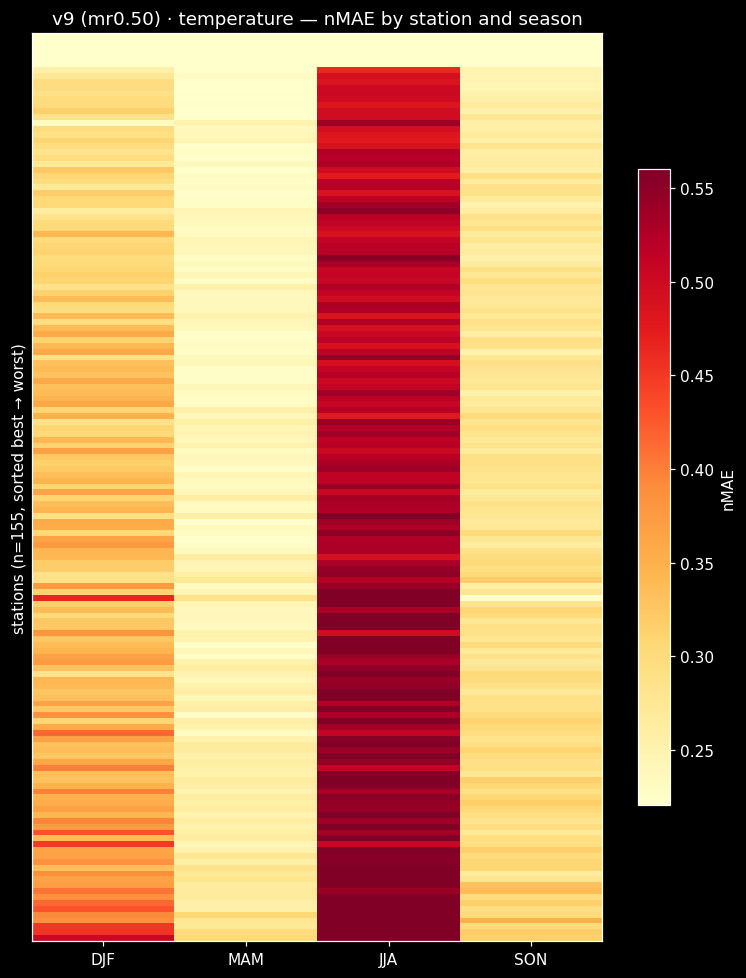

,DJF,MAM,JJA,SON
terrain,,,,
mountain,0.343,0.241,0.538,0.272
valley,0.304,0.228,0.493,0.268


,DJF,MAM,JJA,SON,worst season,terrain
JUN,0.504,0.301,0.655,0.315,JJA,mountain
MRP,0.465,0.286,0.657,0.000,JJA,mountain
DIA,0.453,0.297,0.693,0.319,JJA,mountain
GOR,0.451,0.271,0.640,0.300,JJA,mountain
ANT,0.449,0.244,0.505,0.292,JJA,mountain
COV,0.430,0.255,0.615,0.293,JJA,mountain
ULR,0.429,0.256,0.533,0.269,JJA,mountain
EGH,0.416,0.254,0.577,0.316,JJA,mountain
ROE,0.416,0.229,0.508,0.294,JJA,mountain
SBO,0.406,0.267,0.541,0.336,JJA,valley


In [9]:
# ── Station × season heatmap for one variable ────────────────────────────────
SEASON_VAR = "temperature"      # ← change variable
vi = VARS.index(SEASON_VAR)
ns = (A["svs"][:,vi,:] / np.maximum(C["svs"][:,vi,:], 1)) / STD[:,vi:vi+1]   # (N,4) nMAE
order = np.argsort(np.nanmean(ns, axis=1))

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(ns[order], aspect="auto", cmap="YlOrRd",
               vmin=np.nanpercentile(ns,5), vmax=np.nanpercentile(ns,95))
ax.set_xticks(range(4)); ax.set_xticklabels(SEASONS)
ax.set_yticks([]); ax.set_ylabel(f"stations (n={N}, sorted best → worst)")
ax.set_title(f"{RUN_INSPECT} ({MR}) · {SEASON_VAR} — nMAE by station and season")
plt.colorbar(im, ax=ax, label="nMAE", shrink=0.7)
plt.tight_layout(); plt.show()

seas_tbl = pd.DataFrame(ns, index=STN, columns=SEASONS)
seas_tbl["worst season"] = seas_tbl[SEASONS].idxmax(axis=1)
seas_tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")
display(seas_tbl.groupby("terrain")[SEASONS].mean().style.format("{:.3f}")
        .set_caption(f"{SEASON_VAR} nMAE by season and terrain"))
display(seas_tbl.nlargest(12, SEASONS).style.format({s:"{:.3f}" for s in SEASONS})
        .set_caption(f"Stations struggling most on {SEASON_VAR}"))